<a href="https://colab.research.google.com/github/junpia1123/BIPN-145/blob/main/Python/DotPlotStats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plot dot plot

This notebook will help you generate "Prism-style" dot plots in Python, inspect the distribution of your data, and run two-sample statistics.
<hr>

## Step 1. Import Data
For this notebook, we can either import our data from a CSV file, or by manually entering the values.

If you'd like to import your data from a CSV file, you will need to follow the instructions for uploading data to Colab on [the home page](https://bipn145.github.io/intro.html). If you are using this option, comment out the lines of code under Option 2.

> **Task**:
> 1. Change `data_1` and `data_2` to be your two groups of data. *Make sure you leave these as lists, with brackets on each end, and each data point separated by a comma.*
> 2. *Optional*: Rename `Condition_1` and `Condition_2`. *Make sure you keep these in single quotes, so Python recognizes them as a string!*

In [1]:
import pandas as pd

# Your trial powers
rest_trials = [14.4802, 79.6669, 34.4718, 19.3361, 30.5214, 10.7568, 45.6588, 32.2844, 13.8997, 30.4529]
math_trials = [83.4965, 47.1966, 100.2842, 109.6772, 96.7858, 18.4824, 64.1847, 20.1677, 27.2034, 40.3622]

# Create a DataFrame
data = pd.DataFrame({
    'Rest': rest_trials,
    'Math': math_trials
})

# Show the data
print(data)

      Rest      Math
0  14.4802   83.4965
1  79.6669   47.1966
2  34.4718  100.2842
3  19.3361  109.6772
4  30.5214   96.7858
5  10.7568   18.4824
6  45.6588   64.1847
7  32.2844   20.1677
8  13.8997   27.2034
9  30.4529   40.3622


## Step 2. Plot Data
Below, we'll use a seaborn plotting function called [swarmplot](https://seaborn.pydata.org/generated/seaborn.swarmplot.html) to plot each of our data points.

### Notes
* This will draw a <font color='gray'>**dotted gray**</font> line for the mean, and a **solid black line** for the median.
* Change the `plt.ylabel` line to add your own label.

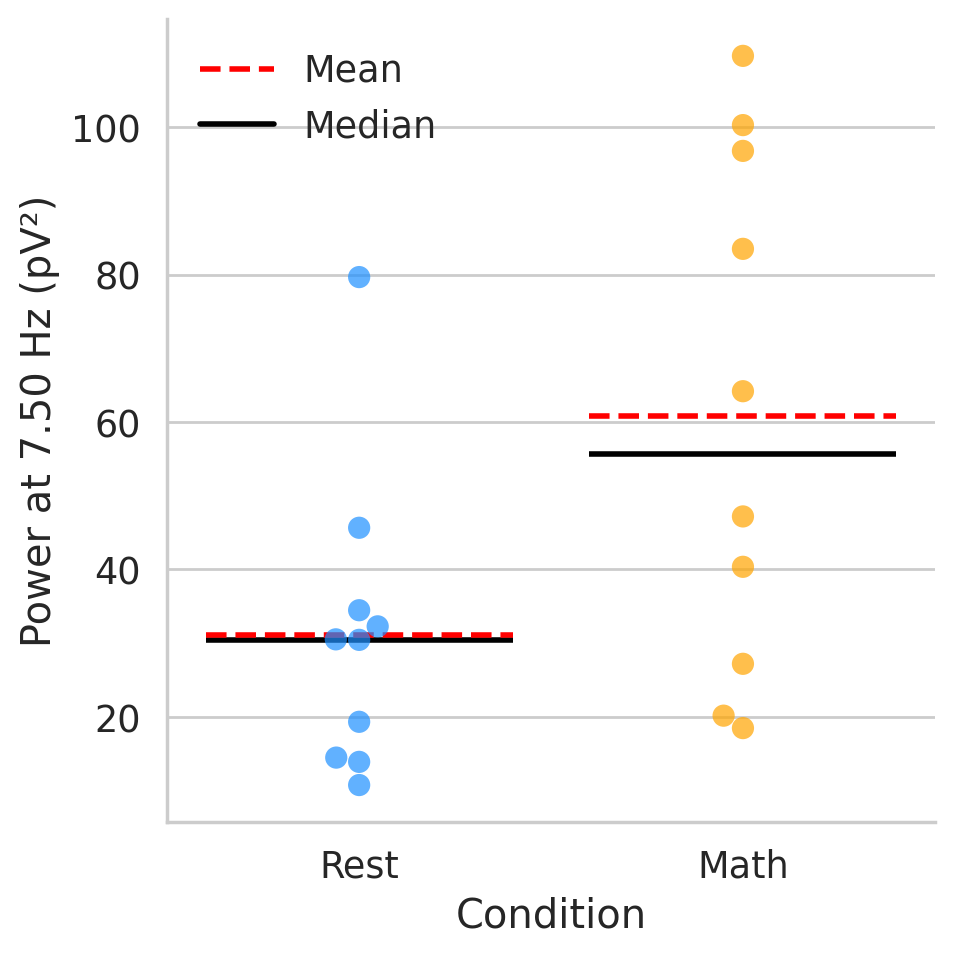

In [6]:
# Import packages
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

# Example DataFrame (replace with your trial data)
# data = pd.DataFrame({'Rest': rest_trials, 'Math': math_trials})

# Set seaborn style
sns.set(style="whitegrid", font_scale=1.2)

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

# Boxplot (mean + median only, minimal clutter)
sns.boxplot(
    data=data,
    showmeans=True,
    meanline=True,
    meanprops={'color': 'red', 'ls': '--', 'lw': 2},
    medianprops={'color': 'black', 'ls': '-', 'lw': 2},
    whiskerprops={'visible': False},
    showcaps=False,
    showfliers=False,
    boxprops={'visible': False}  # hide box
)

# Swarmplot for individual trials
sns.swarmplot(
    data=data,
    palette={'Rest':'dodgerblue','Math':'orange'},  # different colors for conditions
    size=8,
    alpha=0.7
)

# Labels
ax.set_ylabel('Power at 7.50 Hz (pV²)')
ax.set_xlabel('Condition')

# Custom legend for mean and median lines
custom_lines = [
    Line2D([0],[0], color='red', ls='--', lw=2),
    Line2D([0],[0], color='black', ls='-', lw=2)
]
ax.legend(custom_lines, ['Mean', 'Median'], frameon=False)

# Remove top and right spines
sns.despine(ax=ax)

# Tight layout
plt.tight_layout()
plt.show()

## Step 3. Check to see how skewed the data is

Before we run any hypothesis tests, we need to know if our data is skewed or not. To test for skewness, we can use [`stats.skewtest`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skewtest.html#scipy.stats.skewtest) to test. This method implements the <a href="https://www.jstor.org/stable/2684359?seq=1">D'Agostino-Pearson skewness test</a>, one of many different tests that can be used to check the normality of a distribution. **If the skew test gives us a p-value of less than 0.05, the population is skewed.**

> **Note:** `skewtest` requires **at least 8 samples**. If your group has fewer than 8 data points, skip to the **Kolmogorov-Smirnov test** option below instead.

>**Task**: Run the cell below, but then change the `sample` to `data_2` (or create a separate cell for `data_2`) to test your second group of data points.

In [7]:
from scipy import stats

sample = data_1 # Choose which data to use

stat,pvalue = stats.skewtest(sample) # Run the skew test

# Print the p value of the skew test up to 30 decimal points
print('The skewtest p-value is ' + '%.30f' % pvalue)

plt.hist(sample) # Create a histogram
plt.ylabel('Observations')
plt.xlabel('Thing we\'re measuring')
plt.show()

NameError: name 'data_1' is not defined

The skewtest p-value is 0.021832545593646387332986691376


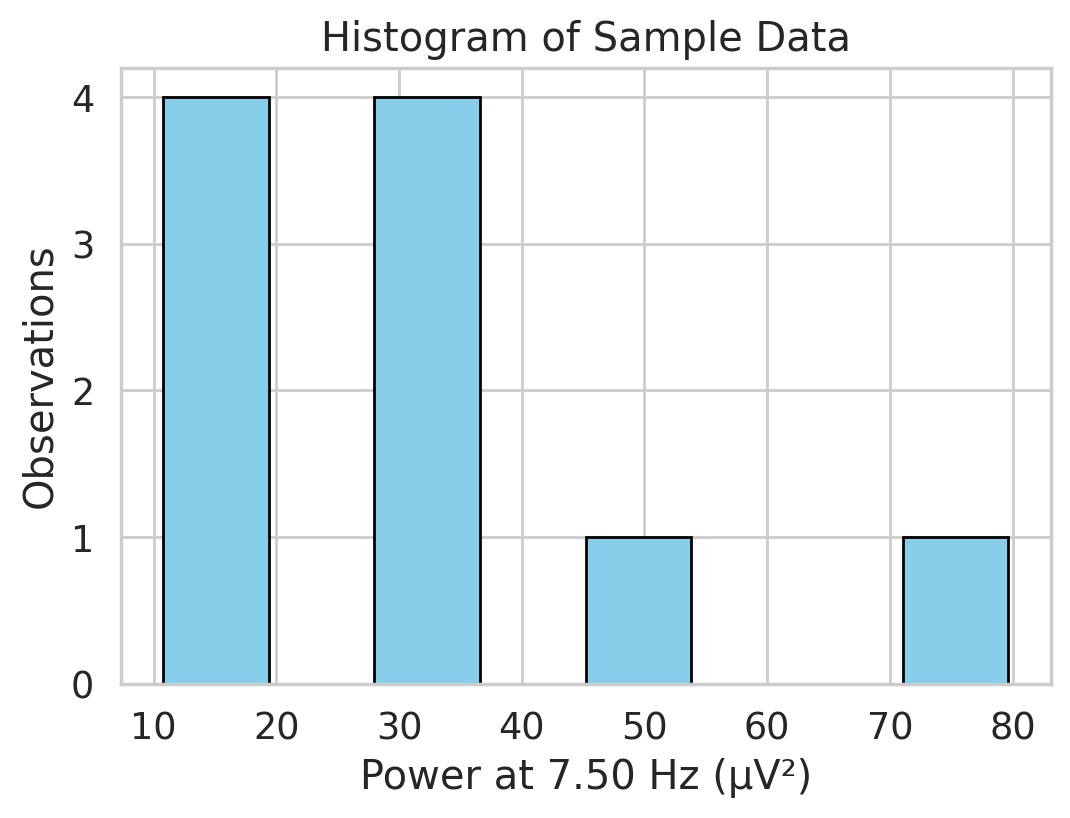

In [9]:
# Import packages
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# Example data: replace with your trial powers
data_1 = [14.4802, 79.6669, 34.4718, 19.3361, 30.5214, 10.7568, 45.6588, 32.2844, 13.8997, 30.4529]

# Choose which sample to test
sample = data_1

# Run skewness test
stat, pvalue = stats.skewtest(sample)

# Print p-value up to 30 decimal points
print('The skewtest p-value is %.30f' % pvalue)

# Create histogram
plt.figure(figsize=(6,4))
plt.hist(sample, bins=8, color='skyblue', edgecolor='black')
plt.ylabel('Observations')
plt.xlabel('Power at 7.50 Hz (µV²)')
plt.title('Histogram of Sample Data')
plt.show()

### Option B: Kolmogorov-Smirnov test (for small samples)

The [Kolmogorov-Smirnov (KS) test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kstest.html) compares your sample against a theoretical normal distribution and works for any sample size. **If the KS test gives a p-value of less than 0.05, the data significantly deviates from normal.**

>**Task**: Change `sample` to `data_1` or `data_2` and run the cell.

KS statistic: 0.2316
KS p-value:   0.580107712870957858974918508466


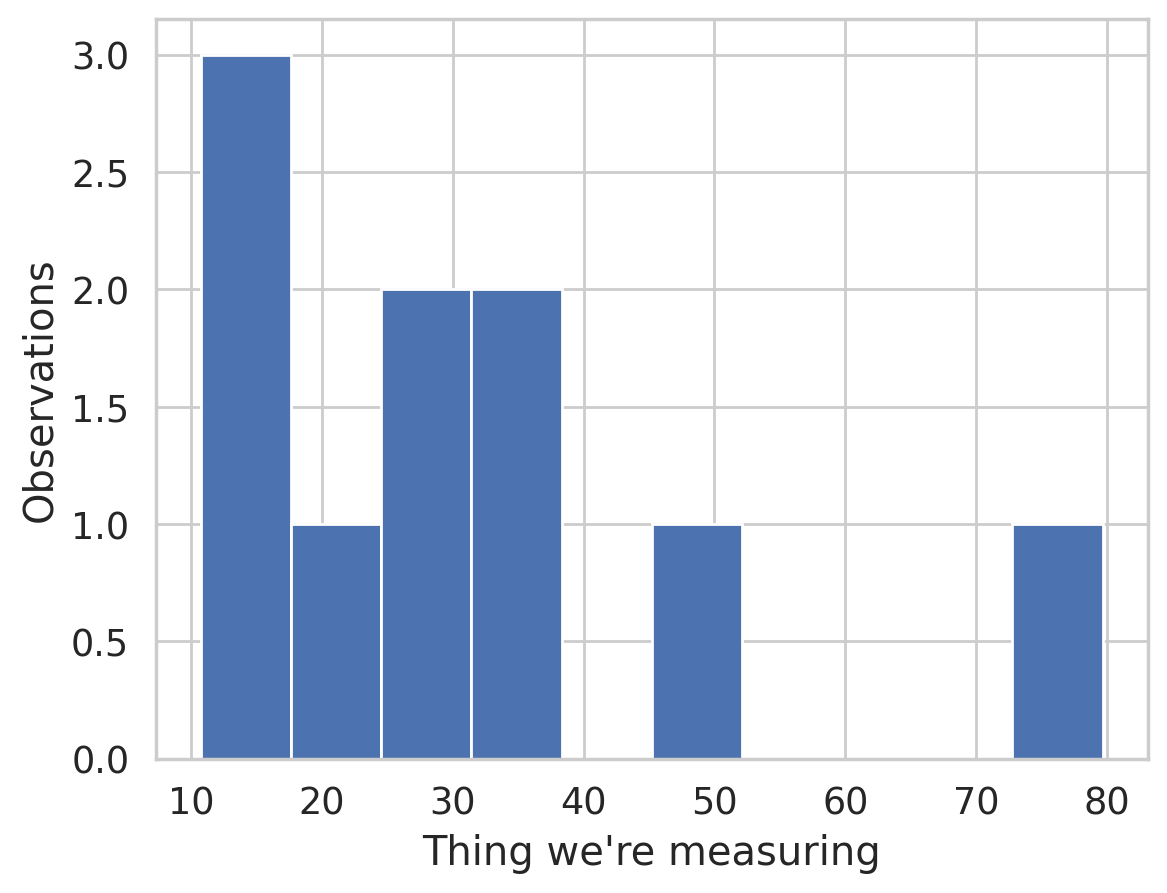

In [10]:
import numpy as np

sample = data_1  # Choose which data to use

# Kolmogorov-Smirnov test for normality
# Tests whether the sample could have come from a normal distribution.
# Works for any sample size (including n < 8).
# If p < 0.05, the data significantly deviates from normal (i.e., it is skewed).
stat, pvalue = stats.kstest(sample, 'norm',
                            args=(np.mean(sample), np.std(sample)))

print('KS statistic: ' + str(round(stat, 4)))
print('KS p-value:   ' + '%.30f' % pvalue)

plt.hist(sample)
plt.ylabel('Observations')
plt.xlabel('Thing we\'re measuring')
plt.show()

KS statistic: 0.2351
KS p-value:   0.561551007593994677691284778120


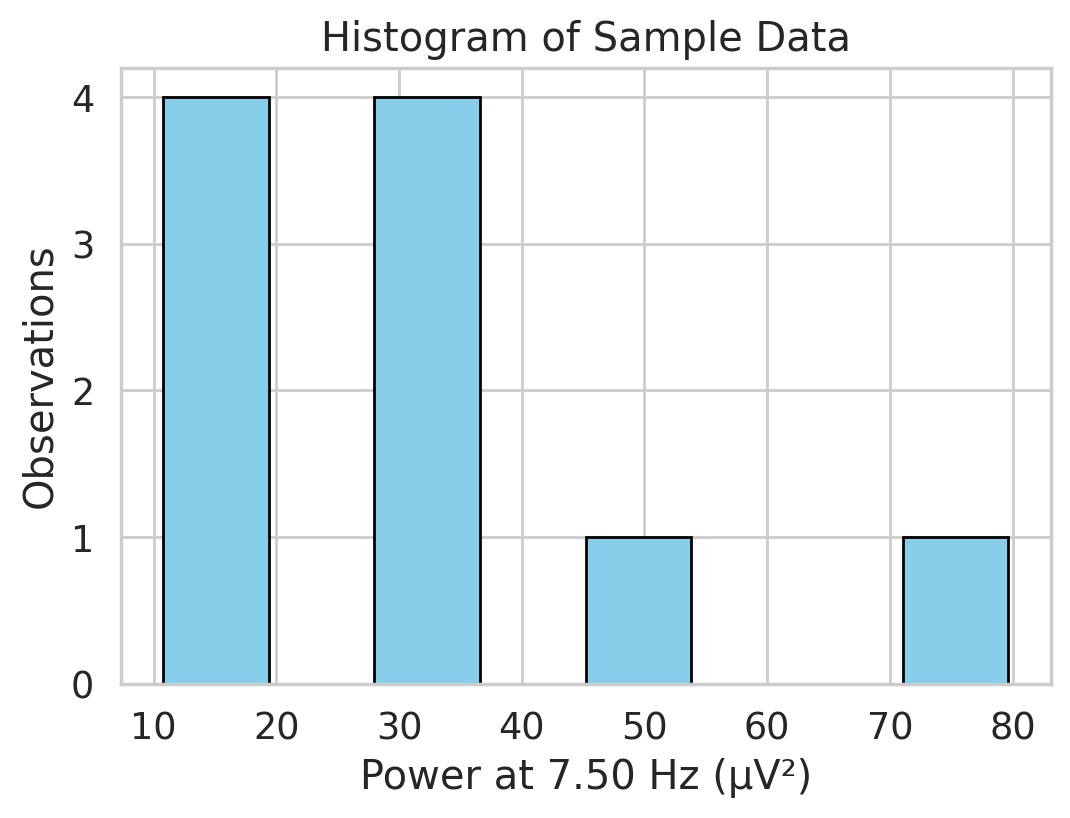

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sample = data_1  # Replace with your trial data

# Compute sample mean and standard deviation (sample std)
mean_sample = np.mean(sample)
std_sample = np.std(sample, ddof=1)

# Kolmogorov-Smirnov test for normality
stat, pvalue = stats.kstest(sample, 'norm', args=(mean_sample, std_sample))

print('KS statistic: ' + str(round(stat, 4)))
print('KS p-value:   ' + '%.30f' % pvalue)

# Histogram
plt.figure(figsize=(6,4))
plt.hist(sample, bins=8, color='skyblue', edgecolor='black')
plt.ylabel('Observations')
plt.xlabel('Power at 7.50 Hz (µV²)')
plt.title('Histogram of Sample Data')
plt.show()

## Step 4. Run two-sample statistics

### *Inferential statistics* generalize from observed data to the world at large
Most often, the goal of our hypothesis testing is to test whether or not two distributions are different, or if a distribution has a different mean than the underlying population distribution.

The SciPy stats package has [many hypothesis testing tools](https://docs.scipy.org/doc/scipy/reference/stats.html). For many simple cases in biology or neuroscience research, we'd like to test whether two or more distributions are different from eachother.

If we know our distributions are normal (they're generated from a normal distribution!) we can use **parametric statistics** to test our hypothesis. To test for differences between normal populations, we can use the independent t-test in our stats package: `stats.ttest_ind()`.

If we had paired samples, we would use a dependent t-test [as seen here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html#scipy.stats.ttest_rel).

If one of our populations is skewed, however, we **cannot use a t-test**. A t-test assumes that the populations are normally distributed. For skewed populations, we can use either the [Mann-Whitney U](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html#scipy.stats.mannwhitneyu) (for independent samples, `stats.mannwhitneyu()`) or the [Wilcoxon Signed Rank Test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html#scipy.stats.wilcoxon) (for dependent/paired samples,`stats.wilcoxon()`).

Below, there is sample code to run three different statistical tests. **You should use *only* the one that is most appropriate for your data by uncommenting that line.**

In [13]:
print(stats.ttest_ind(data_1,data_2)) # to run an independent t-test
# print(stats.ttest_rel(data_1,data_2)) # to run an dependent t-test
# print(stats.mannwhitneyu(data_1,_2)) # to run a mannwhitneyu
# print(stats.wilcoxon(data_1,data_2)) # to run a wilcoxon signed rank test

NameError: name 'data_2' is not defined

In [18]:
from scipy import stats

# Example data (same subject, Rest vs Math)
data_1 = [14.4802, 79.6669, 34.4718, 19.3361, 30.5214, 10.7568, 45.6588, 32.2844, 13.8997, 30.4529]  # Rest
data_2 = [83.4965, 47.1966, 100.2842, 109.6772, 96.7858, 18.4824, 64.1847, 20.1677, 27.2034, 40.3622]  # Math

# Paired t-test
stat, p = stats.ttest_rel(data_1, data_2)

print(f"Paired t-test: t = {stat:.3f}, p = {p:.5f}")

Paired t-test: t = -2.315, p = 0.04587


In [19]:
# Trial powers
rest_trials = [14.4802, 79.6669, 34.4718, 19.3361, 30.5214, 10.7568, 45.6588, 32.2844, 13.8997, 30.4529]
math_trials = [83.4965, 47.1966, 100.2842, 109.6772, 96.7858, 18.4824, 64.1847, 20.1677, 27.2034, 40.3622]

# Compute means
mean_rest = sum(rest_trials) / len(rest_trials)
mean_math = sum(math_trials) / len(math_trials)

print(f"Mean Rest: {mean_rest:.2f} µV²")
print(f"Mean Math: {mean_math:.2f} µV²")

Mean Rest: 31.15 µV²
Mean Math: 60.78 µV²


That's it for this notebook! You can adapt this code for lots of different projects (including your final project!).